In [ ]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.get_absorption_interval import get_absorption_interval
from processing.parameters import CONTINUUM_WINDOWS, LYA_AIR, NV_AIR 
from utility.get_intercepts_near_line import get_intercepts_near_line

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.signal import argrelmin, argrelmax
from scipy.interpolate import interp1d
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import json
import os

relevant_erq_data_path = "data/relevant_erq_data.json"

pd.options.mode.chained_assignment = None

In [3]:
data = pd.read_json(relevant_erq_data_path)

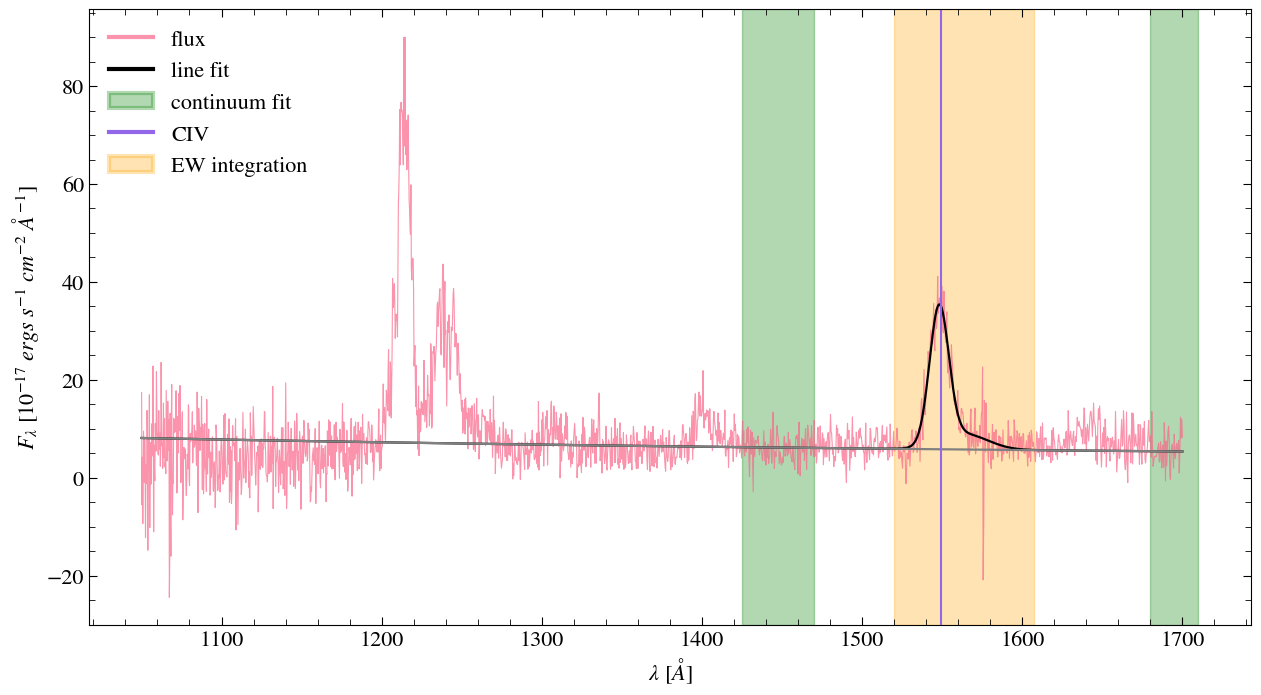


            SDSS: 014111.13-031852.5
            FWHM: 2866.078 vs 2985.648 (Hamann)
            REW: 97.224 vs 101.008 (Hamann) vs 91.83 (fit area)
            kt80: 0.35 vs 0.372 (Hamann)



In [4]:
idx = 6

lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

# flux = convolve(flux, Gaussian1DKernel(1))

flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)

if rejected:
    print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
    plot_spectrum(lam, flux_clean, add_smoothed=False)

flux_sub = flux_clean - continuum if not rejected else None

absorption_interval = get_absorption_interval(lam,flux,ivar)

if absorption_interval is not None:
    bal_mask = (lam > absorption_interval[0]) & (lam < absorption_interval[1])
else:
    bal_mask = None
# bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)

result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

accept_two, p_val = ftest_which_gaussian(result1, result2)

if accept_two:
    sigma_w = result2.params["sigma_w"].value
    sigma_c = result2.params["sigma_c"].value
    mu_w = result2.params["cen_w"].value
    mu_c = result2.params["cen_c"].value

    lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
    upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
    ci = (lower,upper)

    # if sigma_w > sigma_c:
    #     sigma = sigma_w
    #     mu = result2.params["cen_w"].value
    # else:
    #     sigma = sigma_c
    #     mu = result2.params["cen_c"].value
    # ci = (mu-2*sigma, mu+2*sigma)
else:
    mu = result1.params["center"].value
    sigma = result1.params["sigma"].value
    ci = (mu-3*sigma, mu+3*sigma)

# ci = (mu-2*sigma, mu+2*sigma)

plot_mask = (lam >= 1050) & (lam <= 1700)
continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

if absorption_interval is not None:
    if accept_two:
        line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
            shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
            shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
            )
    else:
        line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
            shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
            shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
            )
else:
    if accept_two:
        line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
            shaded_regions_colors=["green"]*2+["orange"],
            shaded_regions_label=["continuum fit"]*2+["EW integration"]
            )
    else:
        line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
            shaded_regions_colors=["green"]*2+["orange"],
            shaded_regions_label=["continuum fit"]*2+["EW integration"]
            )

out_str = f'''
            SDSS: {data["sdss_name"][idx]}
            FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][idx],3)} (Hamann)
            REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][idx],3)} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
            kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][idx],3)} (Hamann)
'''

print(out_str)

### apply what i already have

In [5]:
# get interval between lines, then the minimum, i.e. the point where the lines intersect
interval_mask = (lam <= NV) & (lam >= LYA)
interval_min = np.argmin(flux[interval_mask])

local_min_lam = lam[interval_mask][interval_min]

# get the lambdas at which LYA intersects with the continuum on the left, and NV on the right
lower_lya, _ = get_intercepts_near_line(lam,flux,continuum,line_lambda=LYA)
_, upper_nv = get_intercepts_near_line(lam,flux,continuum,line_lambda=NV)

# each region is from the middle point to each their continuum intersects
lya_region = (lower_lya,local_min_lam)
nv_region = (local_min_lam,upper_nv)

In [6]:
# fit windows
lya_window = (LYA-100,LYA+100)
nv_window = (NV-100,LYA+100)

# masks that indicate the respective regions
mask_lya = (lam >= lya_region[0]) & (lam <= lya_region[1])
mask_nv = (lam >= nv_region[0]) & (lam <= nv_region[1])

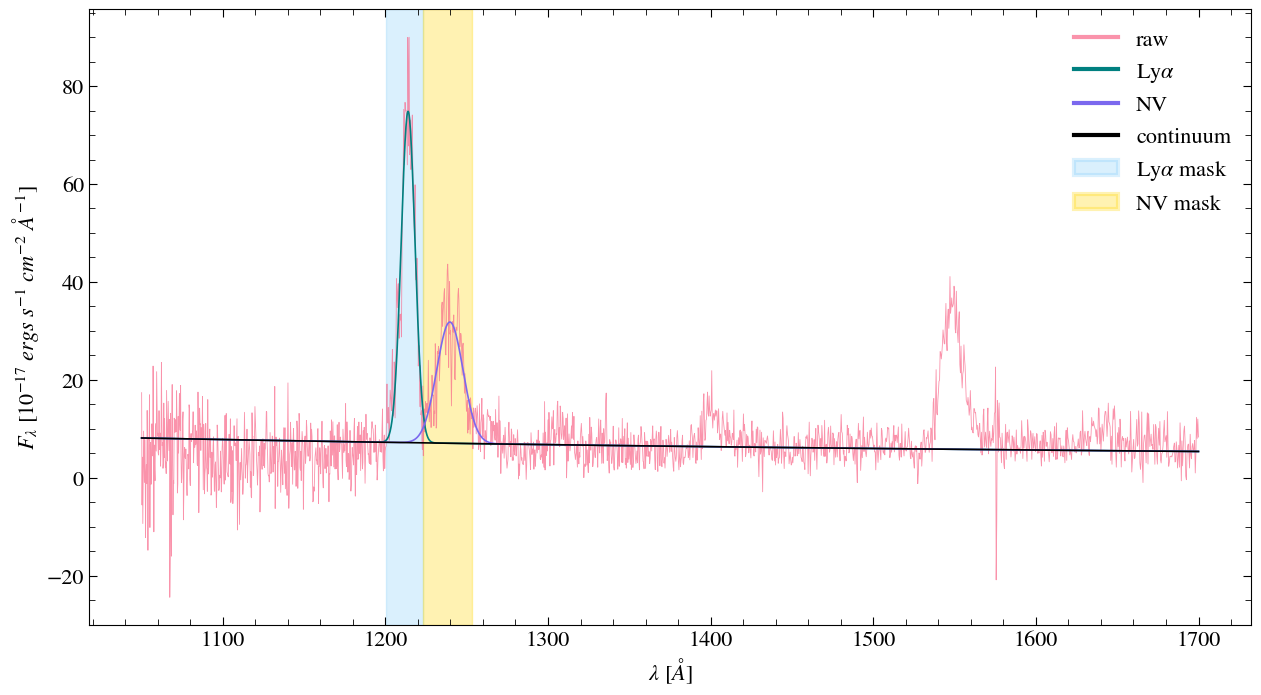

In [ ]:
# fit lines to continuum in respective window, masking the other region, then check which profile to plot
result1_nv, profile1_nv = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=mask_lya,window=nv_window)
result2_nv, profile2_nv = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=mask_lya, window=nv_window, single_result=result1)

accept_two_nv, p_val_nv = ftest_which_gaussian(result1_nv, result2_nv)
if accept_two_nv:
    profile_nv = profile2_nv
else:
    profile_nv = profile1_nv

result1_lya, profile1_lya = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=mask_nv,window=lya_window)
result2_lya, profile2_lya = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=mask_nv, window=lya_window, single_result=result1)

accept_two_lya, p_val_lya = ftest_which_gaussian(result1_lya, result2_lya)
if accept_two_lya:
    profile_lya = profile2_lya
else:
    profile_lya = profile1_lya

plot_spectrum(lam[plot_mask],flux[plot_mask],add_smoothed=False,additional_flux=[profile_lya[plot_mask]+continuum[plot_mask],profile_nv[plot_mask]+continuum[plot_mask],continuum[plot_mask]], additional_flux_label=[r"Ly$\alpha$","NV","continuum"],additional_flux_color=["Teal","MediumSlateBlue","black"],shaded_regions=[lya_region,nv_region],shaded_regions_label=[r"Ly$\alpha$ mask","NV mask"],shaded_regions_colors=["LightSkyBlue","Gold","YellowGreen"],line_width_factor=1.5)

### new